# Calibration process analysis
Ideas:
* Hacer un diagrama por sesion calibracion en la que se muestren los solapamientos de rondas
* hacen un diagrama por sesion de calibración el el que se muestren los histogramas de las medidas de frecuencia, la media y la mediana
* Hacer una diagrama de evolucion de la frecuencia/magnitud de stars3 con el tiempo incluyendo todas las calibraciones, para ver si vemos algun patron de descenso de iluminación

## Dataset
To perform the analysis, we ran 5 calibration processes, alternating between low light and high light calibrations. The we exported the rounds and samples into CSV files. To analyze the dataset, we use `polars`, a PANDAS-like Python package but very effecient and blazingly fast.

## Global imports

In [1]:
import os
from enum import StrEnum
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt

### Convenient helpers

#### Column enumeration

Column enumeration helps us to manitplate the columns without having to remember or hardcode the actual column names, which are only defined once here.

In [2]:
class COL(StrEnum):
    MODEL = "Model"
    NAME = "Name"
    MAC = "MAC"
    SESSION = "Session (UTC)"
    ROLE = "Role"
    ROUND = "Round"
    TIME = "Timestamp"
    FREQ = "Freq (Hz)"
    BOX_T = "Box Temp (℃)"
    SEQ = "Sequence #"
    STDEV = "σ (Hz)"
    MAG = "Mag"
    ZP = "ZP"
    NSAMPLES = "# Samples"
    DELTA_T = "ΔT (s.)"

#### Auxiliar functions

In [226]:
def split_session(session, role):
    tag = session[COL.SESSION][0]
    dataset = session.filter((pl.col(COL.ROLE) == role))
    phot = dataset[COL.NAME][0]
    mean = dataset.select(pl.col(COL.FREQ).mean()).item()
    median = dataset.select(pl.col(COL.FREQ).median()).item()
    freqs = dataset[COL.FREQ].to_numpy()
    return phot, freqs, mean, median

In [227]:
def histogram(data, name, label, bins, title=None, mean=None, median=None):
    title = title or f"{name} {label} histogram"
    plt.hist(data, bins=bins)  # adjust bins as needed
    if mean is not None:
        plt.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
    if median is not None:
        plt.axvline(median, color='red', linestyle=':', label=f'Median = {median:.3f}')
    plt.xlabel(label)
    plt.ylabel("Counts")
    plt.title(title)
    if not all([mean is None, median is None]):
        plt.legend()
    plt.show()

In [296]:
def histogram2(
    datas: list, 
    names: list, 
    labels: list, 
    bins: list, 
    titles: list | None=None, 
    means: list | None=None, 
    medians: list | None=None
) -> None:
    # Crear figura con 1 fila, 2 columnas para dos histogramas
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    means = means or [None, None]
    medians = medians or [None, None]
    titles = titles or [None, None]
    for i, (ax, data, basket, name, label, title, mean, median) in enumerate(zip(axes, datas, bins, names, labels, titles, means, medians)):
        ax.hist(data, bins=basket, edgecolor='blue')
        if mean is not None:
            ax.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        if median is not None:
            ax.axvline(median, color='red', linestyle=':', label=f'Median = {median:.3f}')
        if title is not None:
            ax.set_title(title)
        ax.set_xlabel(label)
        ax.set_ylabel(f"Count @ binsize ={basket}")
        ax.legend()
    plt.tight_layout()
    plt.show()

## Input files

In [280]:
SAMPLES_FILE = os.path.join("data", "samples_from_20251120_to_20251120.csv")
ROUNDS_FILE =  os.path.join("data", "rounds_from_20251120_to_20251120.csv")

In [298]:
samples = pl.read_csv(SAMPLES_FILE, separator=";", try_parse_dates=True)
rounds = pl.read_csv(ROUNDS_FILE, separator=";", try_parse_dates=True)

In [301]:
rounds

Model,Name,MAC,Session (UTC),Role,Round,Freq (Hz),σ (Hz),Mag,ZP,# Samples,ΔT (s.)
str,str,str,datetime[μs],str,i64,f64,f64,f64,f64,i64,f64
"""TESS-W""","""stars3""","""18:FE:34:CF:E9:A3""",2025-11-20 11:18:15,"""ref""",1,2.931,0.0068,19.332,null,75,26.876
"""TESS-W""","""stars237""","""5C:CF:7F:76:69:E3""",2025-11-20 11:18:15,"""test""",1,2.65,0.016,19.443,20.329755,75,93.315
"""TESS-W""","""stars3""","""18:FE:34:CF:E9:A3""",2025-11-20 11:18:15,"""ref""",2,2.931,0.0082,19.332,null,75,26.715
"""TESS-W""","""stars237""","""5C:CF:7F:76:69:E3""",2025-11-20 11:18:15,"""test""",2,2.66,0.0156,19.439,20.333848,75,93.313
"""TESS-W""","""stars3""","""18:FE:34:CF:E9:A3""",2025-11-20 11:18:15,"""ref""",3,2.929,0.0106,19.333,null,75,27.867
…,…,…,…,…,…,…,…,…,…,…,…
"""TESS-W""","""stars237""","""5C:CF:7F:76:69:E3""",2025-11-20 11:41:48,"""test""",3,0.58,0.0,21.095,20.336177,75,74.651
"""TESS-W""","""stars3""","""18:FE:34:CF:E9:A3""",2025-11-20 11:41:48,"""ref""",4,0.636,0.0013,20.991,null,75,117.068
"""TESS-W""","""stars237""","""5C:CF:7F:76:69:E3""",2025-11-20 11:41:48,"""test""",4,0.58,0.0,21.095,20.336177,75,79.053


## Histograms

### Global histograms

From the samples dataset, we first filter by role and frequency value. Low light calibrations were made typically around 0.5 Hz approx. and high light calibrations were made at 3 Hz approx.

In [302]:
ref_low_samples = rounds.filter( (pl.col(COL.ROLE) == "ref") & (pl.col(COL.FREQ) < 1))
ref_low_freqs = ref_low_samples[COL.FREQ].to_numpy()
mean_low_freq = ref_low_samples.select(pl.col(COL.FREQ).mean()).item()
median_low_freq = ref_low_samples.select(pl.col(COL.FREQ).median()).item()

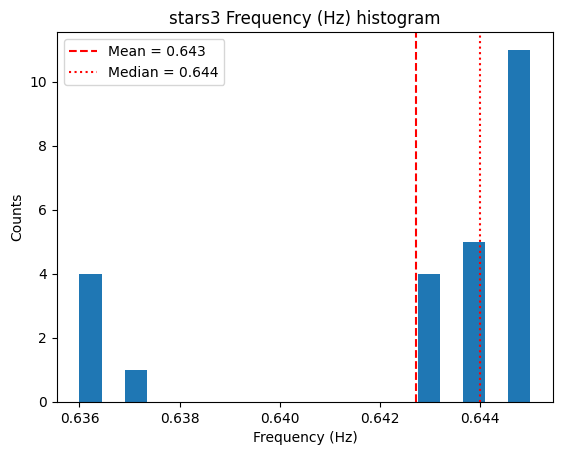

In [303]:
histogram(ref_low_freqs, "stars3", "Frequency (Hz)", 20,mean=mean_low_freq,median=median_low_freq)

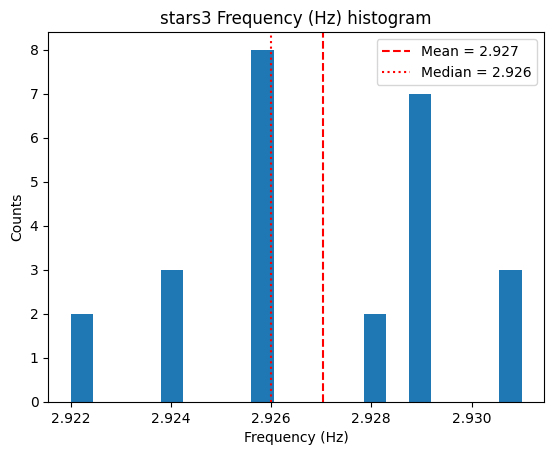

In [304]:
ref_high_samples = rounds.filter( (pl.col(COL.ROLE) == "ref") & (pl.col(COL.FREQ) > 1))
ref_high_freqs = ref_high_samples[COL.FREQ].to_numpy()
mean_high_freq = ref_high_samples.select(pl.col(COL.FREQ).mean()).item()
median_high_freq = ref_high_samples.select(pl.col(COL.FREQ).median()).item()
histogram(ref_high_freqs, "stars3", "Frequency (Hz)", 20,mean=mean_high_freq,median=median_high_freq)

The reference photometer shows an overall, unexpected bimodal frequency distribution, conspicuous in low light conditions. Let's see if this is repliacted across individual calibration sessions.

We first split the datasets into sessions for a total of 10 sessions

In [305]:
# Get a list of DataFrames, partitioned by session tag
sessions = rounds.partition_by([COL.SESSION])
len(sessions)

10

### stars3 reference photometer calibration histograms

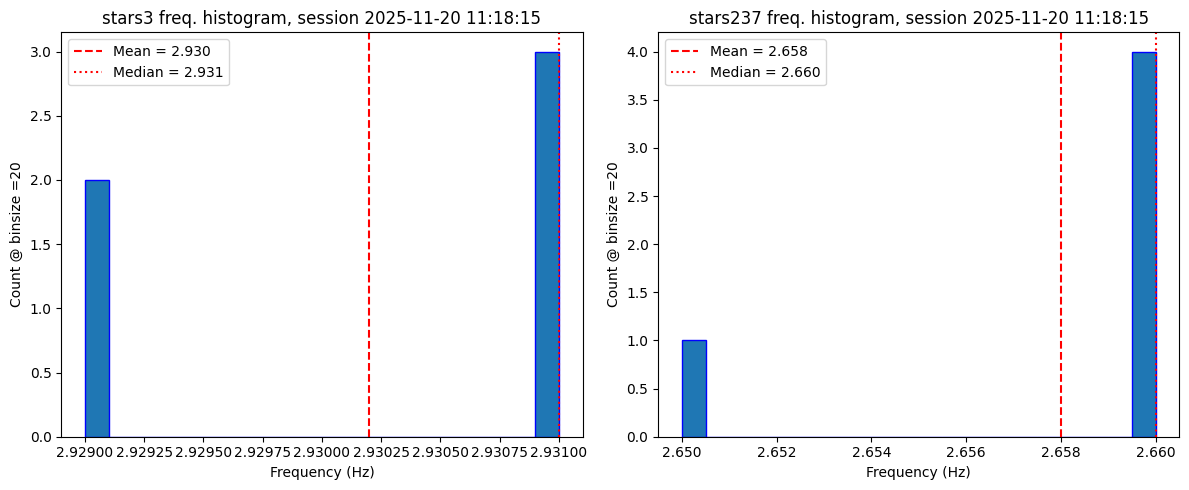

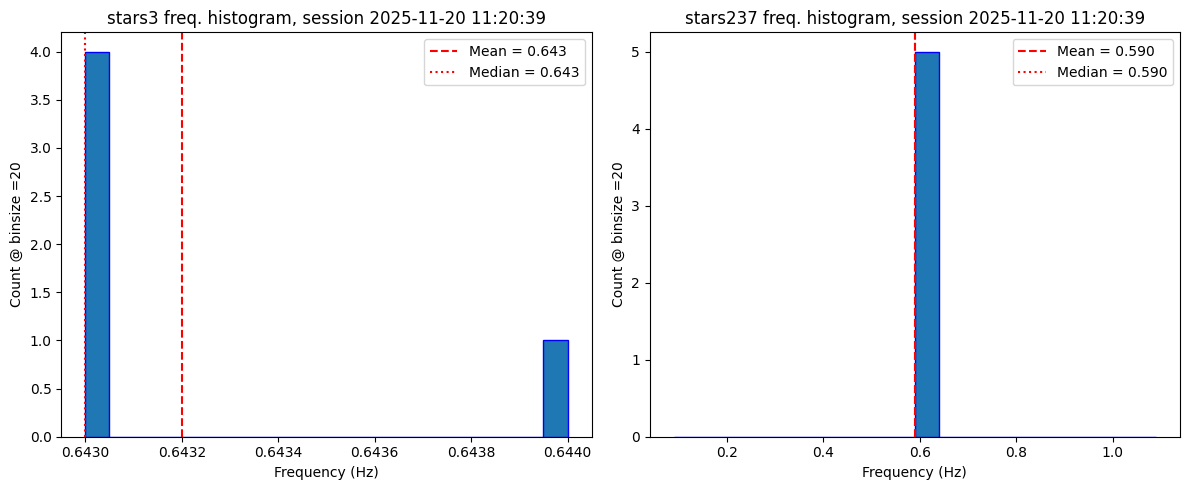

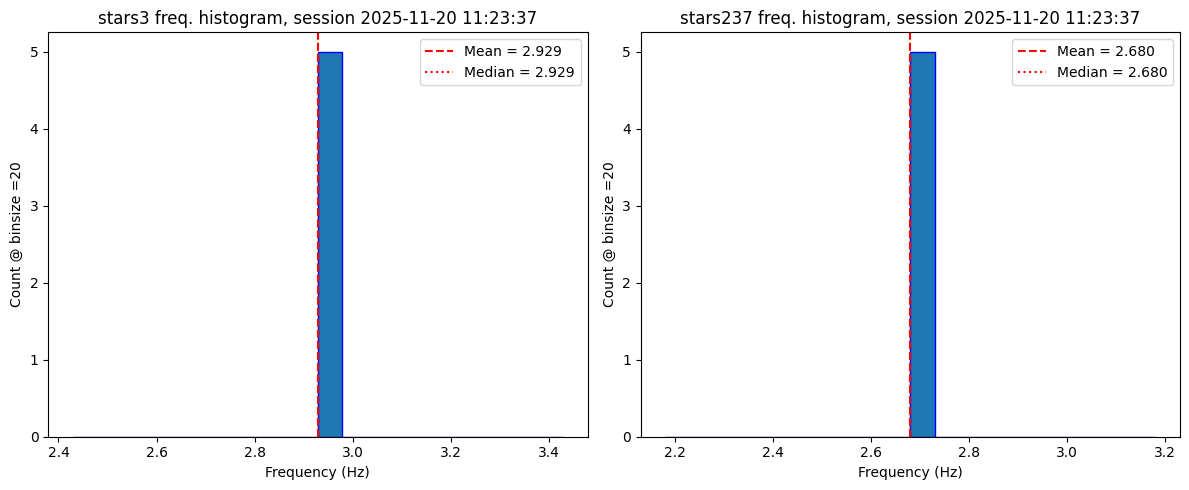

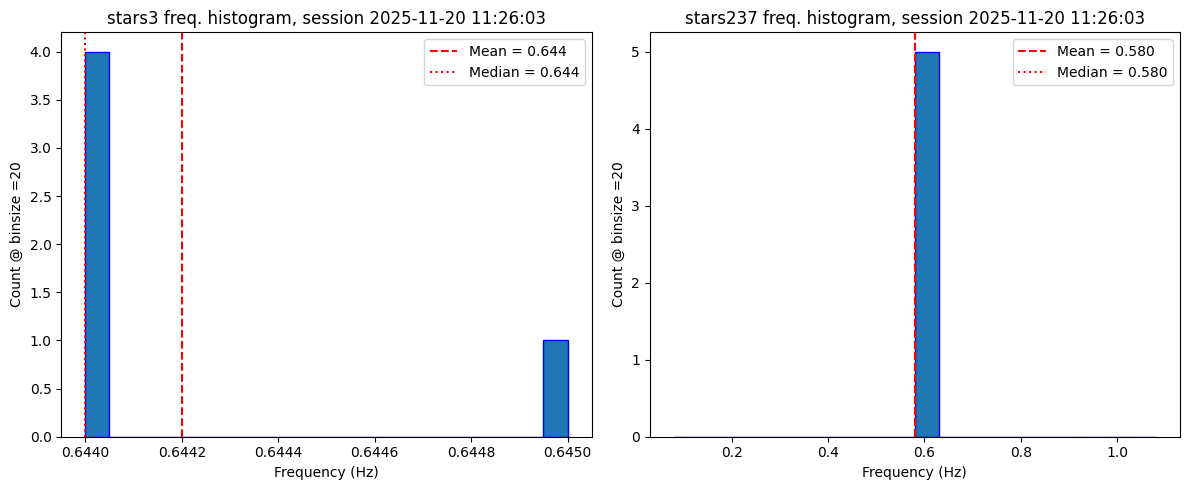

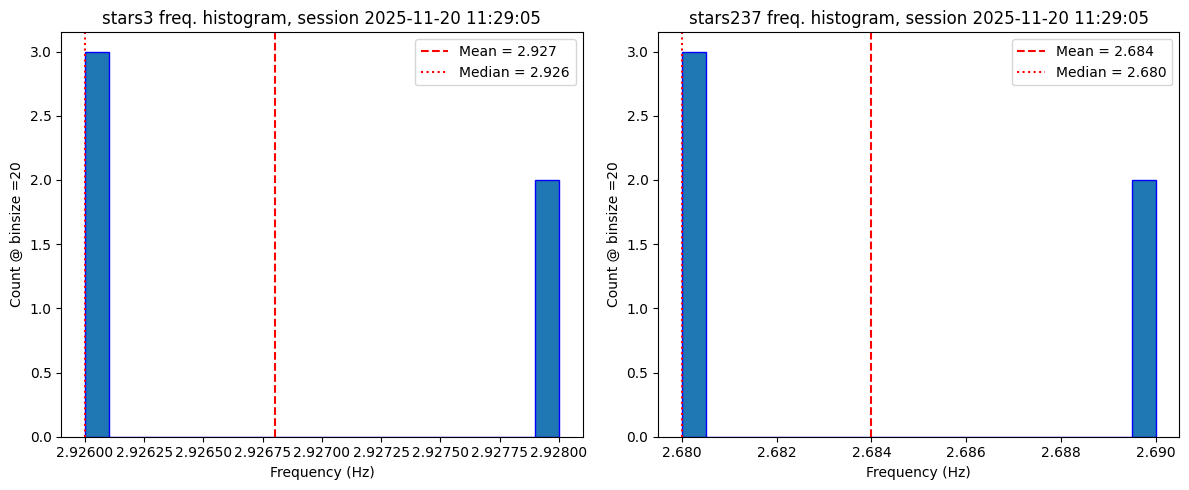

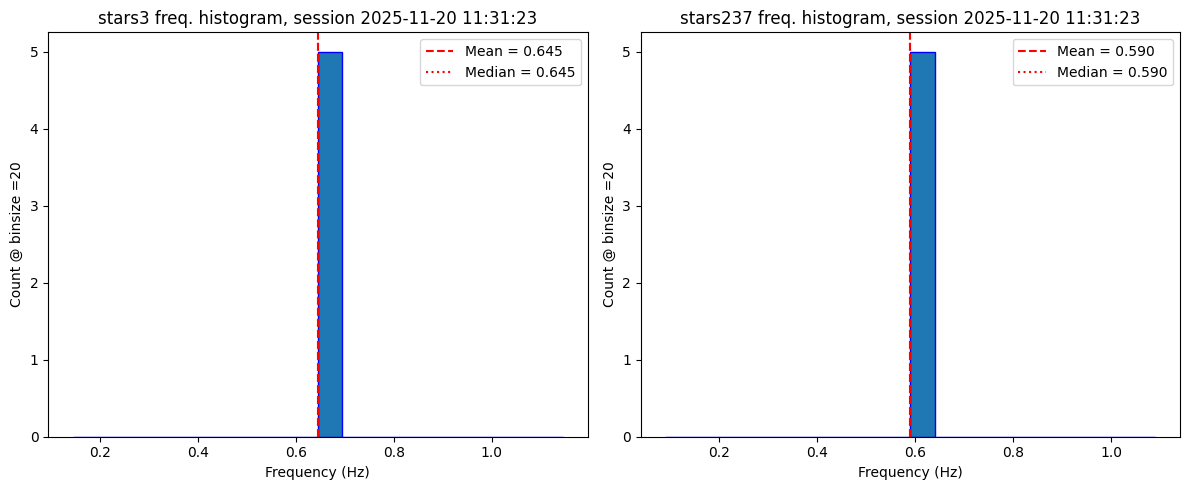

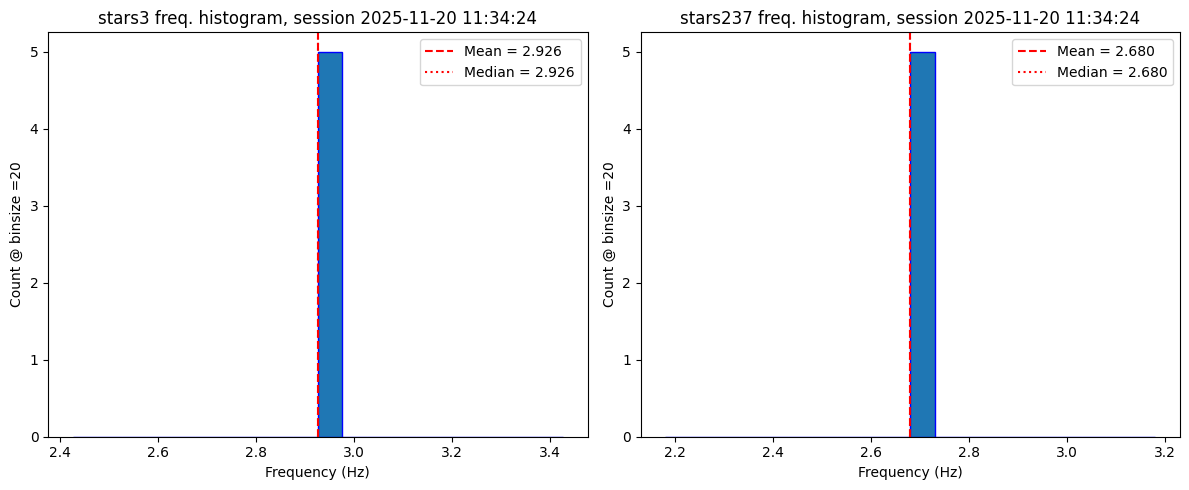

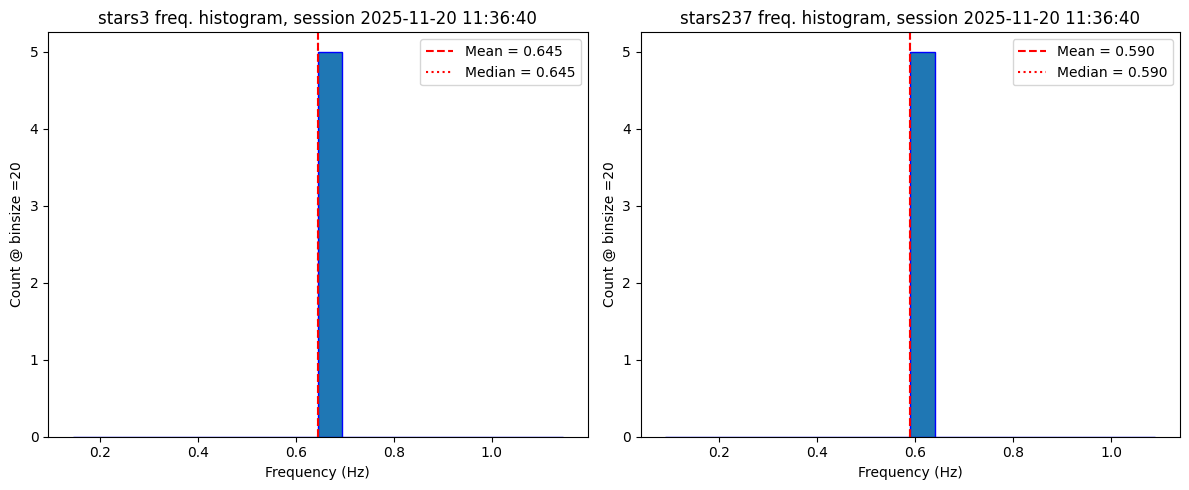

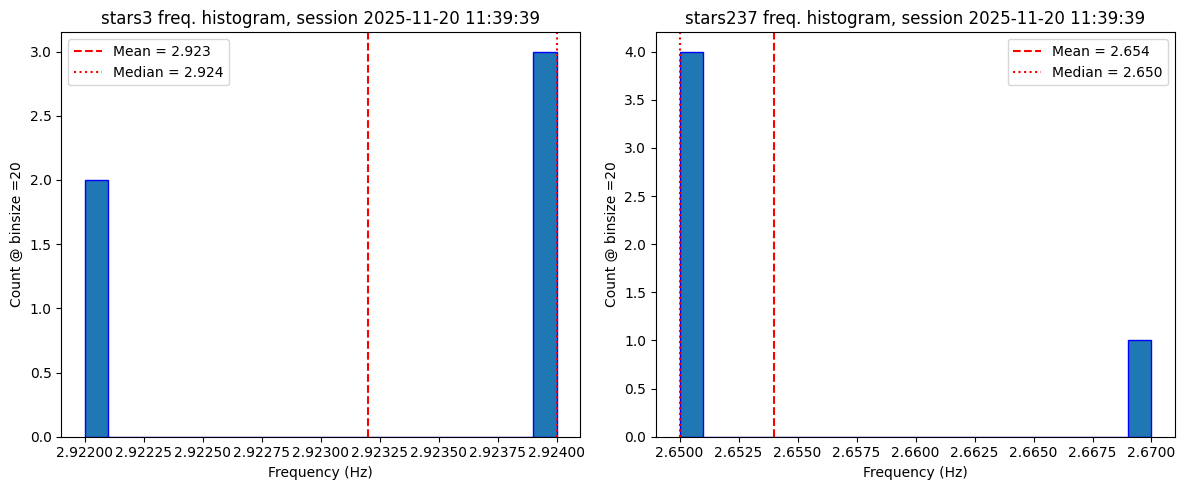

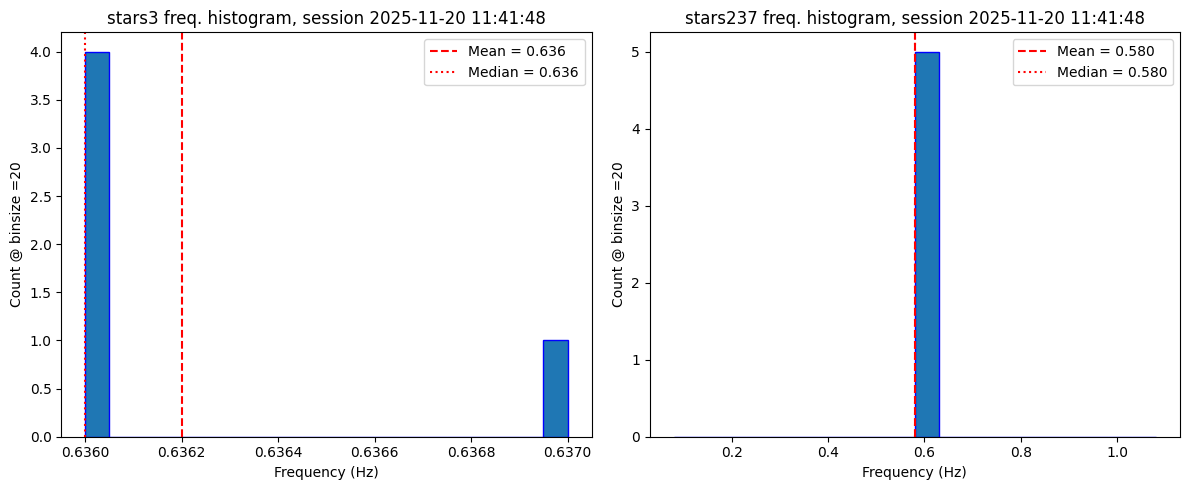

In [307]:
for session in sessions:
    tag = session[COL.SESSION][0]
    r_phot, r_freqs, r_mean, r_median = split_session(session, "ref")
    t_phot, t_freqs, t_mean, t_median = split_session(session, "test")
    r_title = f"{r_phot} freq. histogram, session {tag}"
    t_title = f"{t_phot} freq. histogram, session {tag}"
    histogram2(
        datas=[r_freqs,t_freqs], 
        names=[r_phot, t_phot], 
        labels=["Frequency (Hz)"]*2, 
        bins=['fd', 'fd'], 
        # bins=[20,20], 
        titles=[r_title, t_title], 
        means=[r_mean, t_mean], 
        medians=[r_median, t_median]
        )